# Exposed assets

In this notebook we read Entity files for El Salvador and visualize the Exposures data for maize, beans and sorghum. 

## Read Exposures from Entity files

The `climada.entity` package provides the tools to interact with Entity files.

Exposure data must be stored in the _first sheet_ of the Excel workbook, called 'assets' by convention. The exposure data is stored in the Entity's `exposures` attribute, and is an instance of CLIMADA's [Exposures](https://climada-python.readthedocs.io/en/v6.1.0/user-guide/climada_entity_Exposures.html) class. They don't need to be financial: the units are specified within the file.

Let's set up our project folders and read in the file(s). This notebook (and the following notebooks) is set up to explore a list of different Entity files, each containing a different asset type.

**NOTE:** You can also create Exposures objects from pandas DataFrames, geopandas GeoDataframes, other Excel files, CSVs, HDF5 files, and raster (e.g. TIF) data. See the [CLIMADA User Guide](https://climada-python.readthedocs.io/en/v6.1.0/user-guide/climada_entity_Exposures.html) for the different ways to do this.

In [1]:
from pathlib import Path

# Set the directory where our Entity files are located
ENTITY_DIR = "../data/entity_files_uncalibrated/"
# Give a dictionary of Entity file names
ENTITY_FILES = {
    "maize": "El_Salvador_Entity_Drought_Maize.xlsx",
    "beans": "El_Salvador_Entity_Drought_Beans.xlsx",
    "sorghum": "El_Salvador_Entity_Drought_Sorghum.xlsx"
}
entity_filepaths = {crop: Path(ENTITY_DIR) / filename for crop, filename in ENTITY_FILES.items()}


In [2]:
import copy
from climada.entity import Entity

# Read in the files
entity_dict = {}
for crop, filepath in entity_filepaths.items():
    print(f"Reading {filepath.name}...")
    entity = Entity.from_excel(filepath)

    # After reading in the file, it is a good idea to set additional properties of the Exposures object

    # ref_year:
    # We can optionally set a reference year for the entity, which describes the year (past, present or future) that the data represent.
    # This is required when the Exposures are used in a cost-benefit analysis, comparing risk at two different points in time.
    entity.exposures.ref_year = 2026

    # value_unit:
    # The unit of the exposure values. This needs to be specified but will be read from the Excel file after the next release
    entity.exposures.value_unit = "USD"

    # description:
    # Optional – used for creating plot titles
    entity.exposures.description = f"Exposures for {crop} ({entity.exposures.value_unit})"

    entity_dict[crop] = copy.deepcopy(entity)


# We can then store the exposures in their own dictionary by accessing the `exposures` property:
exposures_dict = {crop: entity.exposures for crop, entity in entity_dict.items()}

Reading El_Salvador_Entity_Drought_Maize.xlsx...
Reading El_Salvador_Entity_Drought_Beans.xlsx...
Reading El_Salvador_Entity_Drought_Sorghum.xlsx...


## Exposures properties

The Excel sheets we just read in are stored in the `Exposures.gdf` (='GeoDataFrame') attribute. We can print some summary information about the Exposures we're working with:

In [3]:
from IPython.display import display

for crop, exp in exposures_dict.items():
    print("")
    print(crop.title())
    print(f"- The Exposures consists of {len(exp.gdf)} points")
    print(f"- Their total value is {exp.gdf['value'].sum():,.0f} {exp.value_unit}")
    print(f"- The points lie between latitudes {exp.latitude.min():.2f} and {exp.latitude.max():.2f}")
    print(f"- The points lie between longitudes {exp.longitude.min():.2f} and {exp.longitude.max():.2f}")
    # If there is region information
    if "region_id" in exp.gdf.columns:
        print(f" -The exposure contains {exp.gdf['region_id'].nunique()} region id(s)")
    # If there is category information
    if "category_id" in exp.gdf.columns:
        print(f"- The exposure contains {exp.gdf['category_id'].nunique()} category id(s)")
    # Find information about impact functions – the column names for these depend on the hazard type
    for col in exp.gdf.columns:
        if col.startswith("impf_"):
            print(f"- The exposure uses {exp.gdf[col].nunique()} impact function(s) (column: '{col}')")

for crop, exp in exposures_dict.items():
    print('\n' + exp.description + ' (first 5 rows)')
    display(exp.gdf.head())



Maize
- The Exposures consists of 14 points
- Their total value is 483,241,910 USD
- The points lie between latitudes 13.38 and 14.13
- The points lie between longitudes -89.90 and -87.89
 -The exposure contains 1 region id(s)
- The exposure contains 1 category id(s)
- The exposure uses 1 impact function(s) (column: 'impf_DR')

Beans
- The Exposures consists of 14 points
- Their total value is 165,044,364 USD
- The points lie between latitudes 13.38 and 14.13
- The points lie between longitudes -89.90 and -87.89
 -The exposure contains 1 region id(s)
- The exposure contains 1 category id(s)
- The exposure uses 1 impact function(s) (column: 'impf_DR')

Sorghum
- The Exposures consists of 14 points
- Their total value is 83,096,725 USD
- The points lie between latitudes 13.38 and 14.13
- The points lie between longitudes -89.90 and -87.89
 -The exposure contains 1 region id(s)
- The exposure contains 1 category id(s)
- The exposure uses 1 impact function(s) (column: 'impf_DR')

Exposure

,category_id,region_id,value,deductible,cover,impf_DR,Value_unit,geometry
0,1,1,7.025272e+07,NaN,NaN,101,USD,POINT (-89.90196 13.85751)
1,1,1,3.532011e+07,NaN,NaN,101,USD,POINT (-88.70886 13.87704)
2,1,1,1.806401e+07,NaN,NaN,101,USD,POINT (-89.07457 14.13120)
3,1,1,5.830404e+07,NaN,NaN,101,USD,POINT (-89.01998 13.83557)
4,1,1,4.488344e+07,NaN,NaN,101,USD,POINT (-89.36268 13.70412)



Exposures for beans (USD) (first 5 rows)


,category_id,region_id,value,deductible,cover,impf_DR,Value_unit,geometry
0,1,1,2.711572e+07,NaN,NaN,102,USD,POINT (-89.90196 13.85751)
1,1,1,1.036067e+07,NaN,NaN,102,USD,POINT (-88.70886 13.87704)
2,1,1,5.157147e+06,NaN,NaN,102,USD,POINT (-89.07457 14.13120)
3,1,1,3.483686e+07,NaN,NaN,102,USD,POINT (-89.01998 13.83557)
4,1,1,1.468466e+07,NaN,NaN,102,USD,POINT (-89.36268 13.70412)



Exposures for sorghum (USD) (first 5 rows)


,category_id,region_id,value,deductible,cover,impf_DR,Value_unit,geometry
0,1,1,2.660003e+07,NaN,NaN,103,USD,POINT (-89.90196 13.85751)
1,1,1,8.942066e+06,NaN,NaN,103,USD,POINT (-88.70886 13.87704)
2,1,1,6.916212e+06,NaN,NaN,103,USD,POINT (-89.07457 14.13120)
3,1,1,1.881553e+06,NaN,NaN,103,USD,POINT (-89.01998 13.83557)
4,1,1,6.890188e+06,NaN,NaN,103,USD,POINT (-89.36268 13.70412)


Points worth noting about the `Entity.exposures` geodataframe:
- The original latitude and longitude columns have been converted to a 'geometry' column. You can still access the raw values with the `Exposures.latitude` and `Exposures.longitude` properties
- The deductible and cover columns are used when asset-level insurance is modelled as an adaptation measure – for now they should be left blank in the Excel workbook
- Each exposure point is acted on by an impact function. This is defined here in the 'impf_DR' column. The last two letters are used to specify the hazard type (here: flood) and is used in matching between datasets. A column 'impf_' with no hazard type is also valid, and will match to any hazard type.

## Visualize the Exposures: points on a map

There are a few ways to visualize an Exposures object. Simplest is to plot them as points on a map with `Exposures.plot_basemap`.

In the plots below we can see the different ways that the Exposures were created:
- The Residential exposures come from a gridded dataset of housing information, and covers the whole Porto Alegre region
- The Schools and Companies exposures come from a database of affected locations, and are limited to areas that were impacted by flooding.

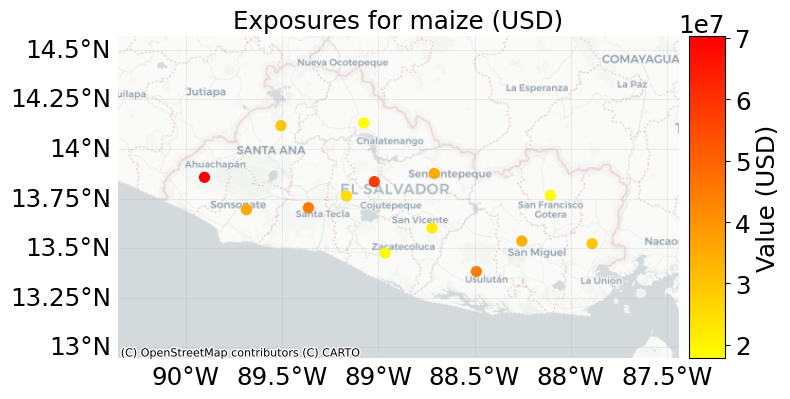

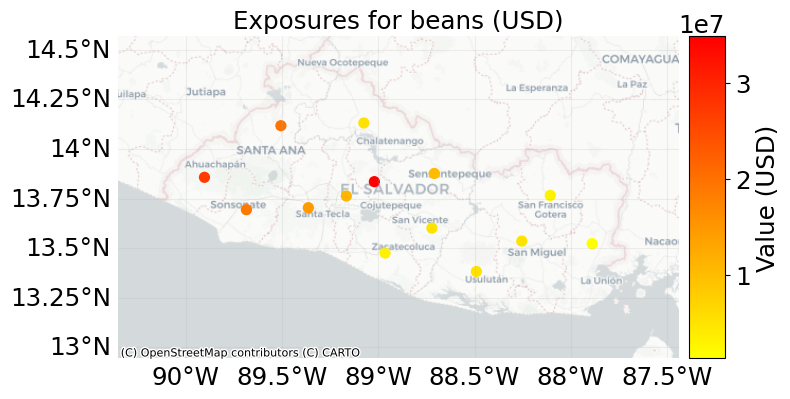

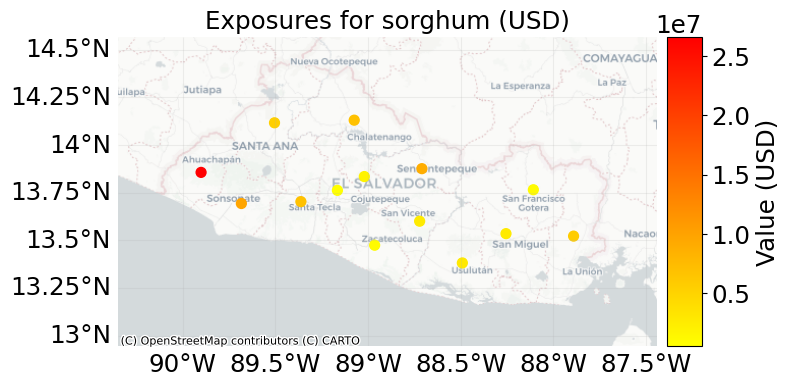

In [6]:
%matplotlib inline
import contextily as ctx

for exp in exposures_dict.values():
    exp.plot_basemap(
        title=exp.description,   # Title for the map. This is the default value.
        ignore_zero=False,       # Whether to plot points with zero value
        buffer=50000,              # Add a buffer around the points to show a larger map region (measured in meters)
        s=50,                     # The size of point markers on the plot
        zoom=8,                  # The detail level of the map. 6 is good for a large country. 8 is good for a state or region. 13 for a city. 15 for a municipality.
        url=ctx.providers.CartoDB.Positron,
                                 # Set a basemap using contextily – here we use CartoDB's Positron which gives a pale, monochrome basemap
                                 #     Another good option is OpenStreetMap's Mapnik (`ctx.providers.OpenStreetMap.Mapnik`)
                                 #     ... this gives a more colourful basemap
                                 #     See all options at: https://xyzservices.readthedocs.io/en/stable/gallery.html
        pop_name=False,          # Add the names of populated places to the map – often not necessary when you have a basemap
        vmax=None,               # Set the maximum value for the colour scale – use this if you want a consistent scale across multiple plots.
        cmap="autumn_r",         # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
        figsize=(8, 10)          # Dimensions of the output figure
    )

## Visualize Exposures: choropleth

The Exposure data here is a single point per department. We can make the data easier to visualize by combining it with shapefile information for the administrative regions:


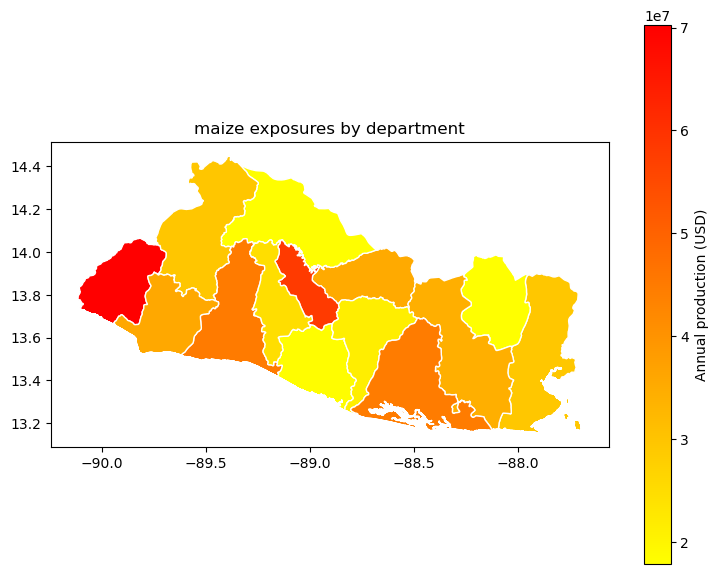

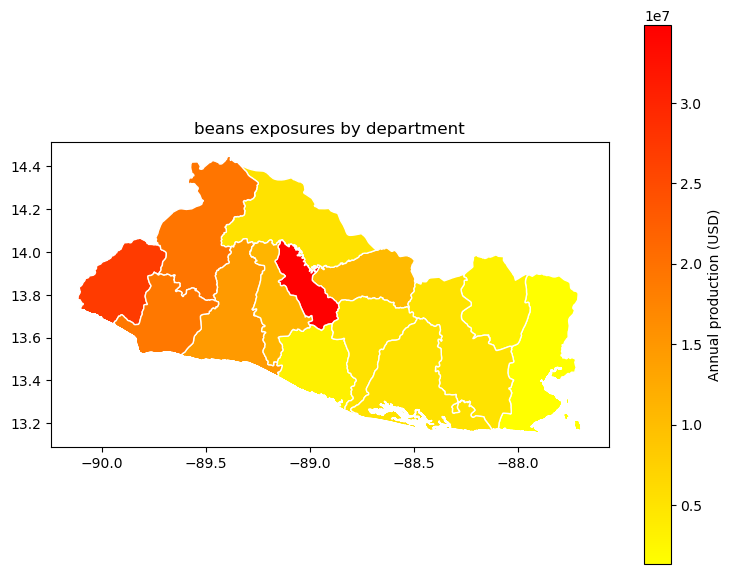

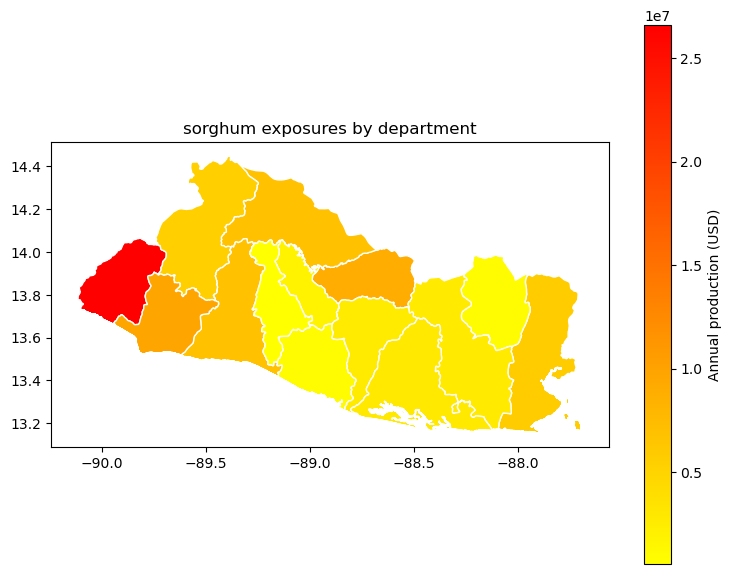

In [9]:
import numpy as np
import geopandas as gpd
import cartopy.crs as ccrs
from climada.util import plot as u_plot 

# Read in the shapefile to a geodataframe using geopandas
shapefile_path = "../data/SLV_departments_shapefile/SLV_ADMIN1_outlines_only.shp"
slv_gdf = gpd.read_file(shapefile_path)

for crop, exp in exposures_dict.items():
    # Spatial join using the exp geodataframe's exp.geometry column 
    exp_gdf = gpd.sjoin(slv_gdf, exp.gdf, how="left", predicate="intersects")
    # Plot the shapefile using the joined 'value' column to colour the shapes
    axis = exp_gdf.plot(
        column="value",
        cmap="autumn_r",
        edgecolor="white",
        legend=True,
        figsize=(9, 7),
        missing_kwds={"color": "lightgrey", "label": "No data"})
    axis.set_title(f"{crop} exposures by department")
    # Set colorbar title
    colorbar = axis.get_figure().get_axes()[1]
    colorbar.set_ylabel(f"Annual production ({exp.value_unit})")